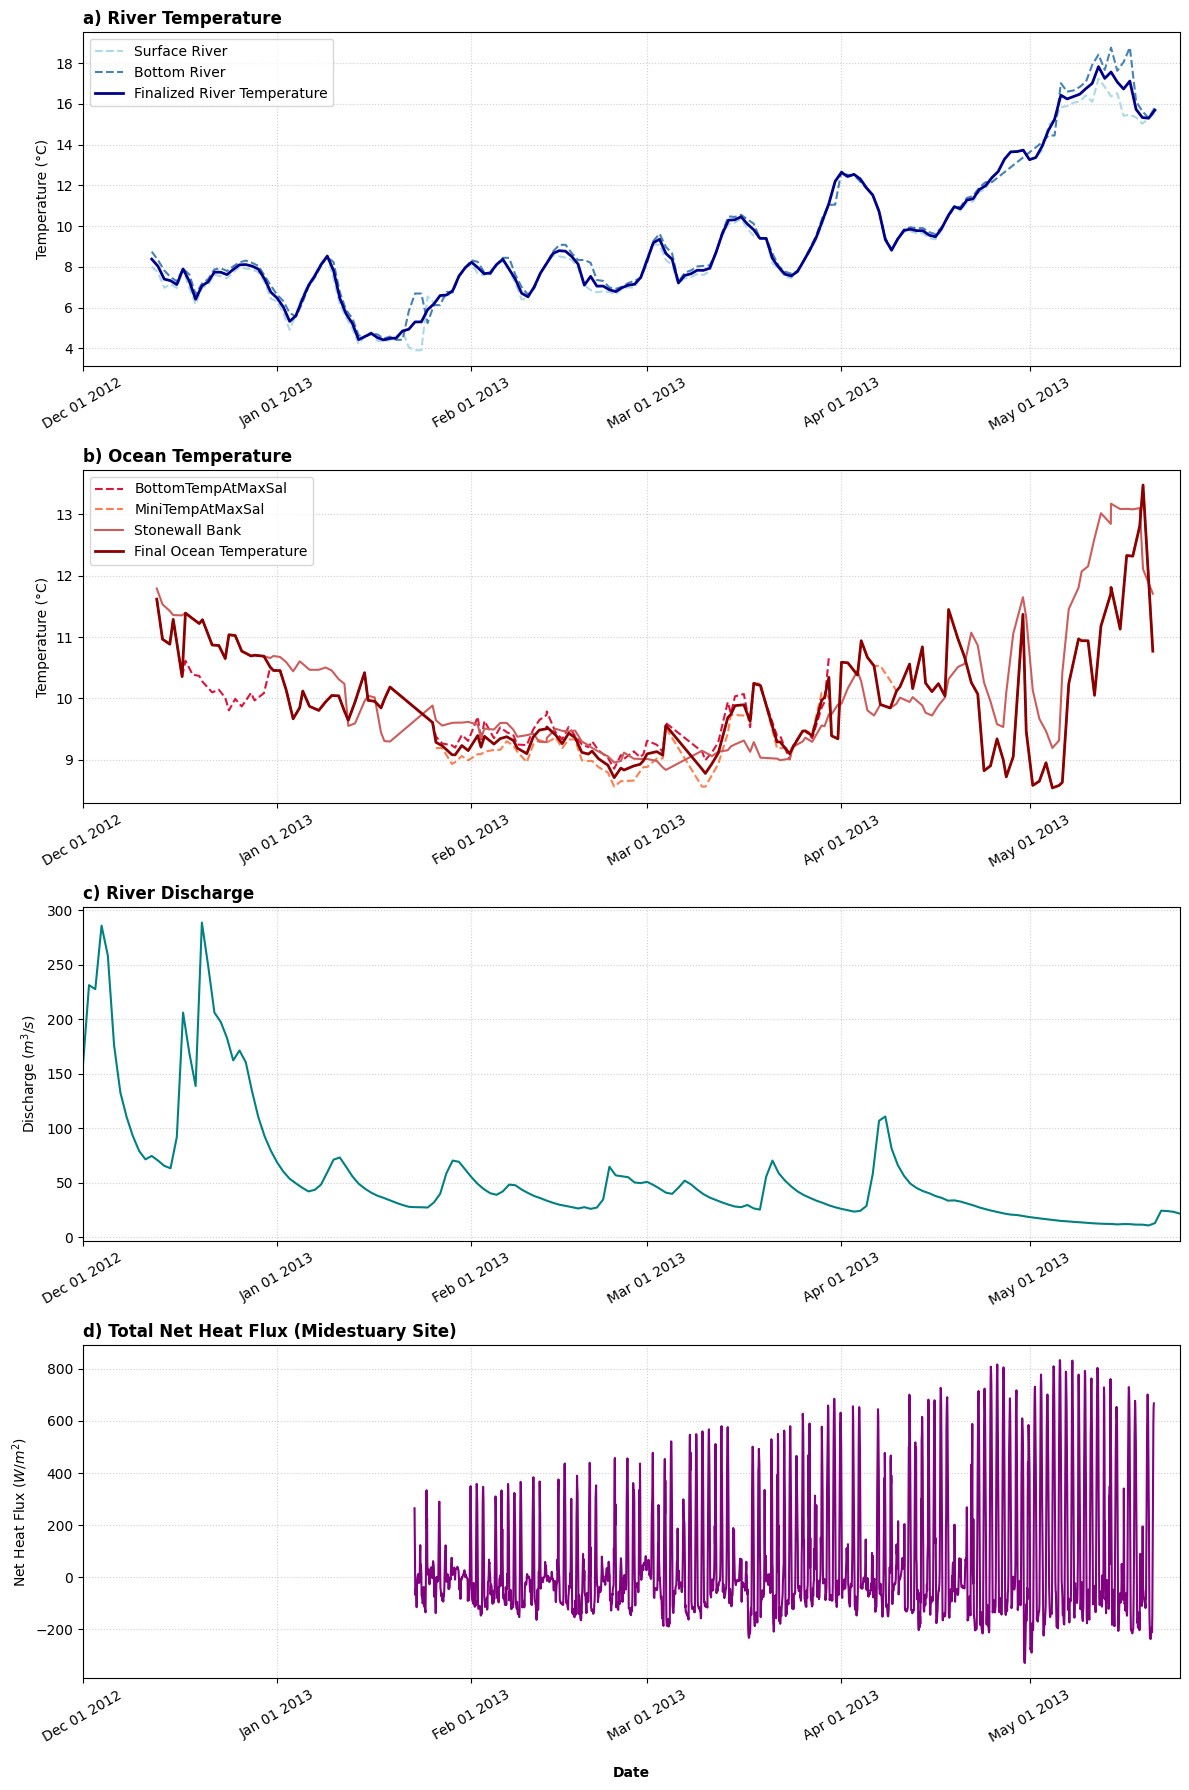

In [2]:
import pandas as pd
import scipy.io as sio
from scipy import signal
from scipy import stats
import numpy as np
import datetime
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re

# --- Load Data ---
oceanDF = pd.read_csv('ocean_temperature12_13.csv', parse_dates = ['DN'])
riverDF = pd.read_csv('FINALIZED_river_temperature12_13.csv', parse_dates = ['dayDN'])
flowDF = pd.read_csv('adjustedflow1213.csv', parse_dates = ['date_only'])
midHeatFluxDF = pd.read_csv('mid_heatflux_2012-2013.csv', parse_dates = ['Tm (UTC)'])

# --- Find Global Min/Max Dates for Axis Alignment ---
min_date = min(riverDF['dayDN'].min(), oceanDF['DN'].min(), flowDF['date_only'].min(), midHeatFluxDF['Tm (UTC)'].min())
max_date = max(riverDF['dayDN'].max(), oceanDF['DN'].max(), flowDF['date_only'].max(), midHeatFluxDF['Tm (UTC)'].max())

# --- Setup Figure and Subplots ---
# Set sharex=True to perfectly align timelines vertically
fig, axs = plt.subplots(4, 1, figsize=(12, 18), sharex=True)
fig.subplots_adjust(hspace=0.35) 

date_form = mdates.DateFormatter('%b %d %Y')

# -------------------------------------------------------------------------
# Subplot a) River Temperature
# -------------------------------------------------------------------------
axs[0].plot(riverDF['dayDN'], riverDF['surfaceRiver'], label='Surface River', color='lightblue', linestyle='--')
axs[0].plot(riverDF['dayDN'], riverDF['bottomRiver'], label='Bottom River', color='steelblue', linestyle='--')
axs[0].plot(riverDF['dayDN'], riverDF['EstimatedTemp'], label='Finalized River Temperature', color='darkblue', linewidth=2)

axs[0].set_title('a) River Temperature', loc='left', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Temperature (°C)')
axs[0].legend(loc='upper left')
axs[0].grid(True, linestyle=':', alpha=0.6)

# -------------------------------------------------------------------------
# Subplot b) Ocean Temperature
# -------------------------------------------------------------------------
axs[1].plot(oceanDF['DN'], oceanDF['BottomTemp'], label='BottomTempAtMaxSal', color='crimson', linestyle='--')
axs[1].plot(oceanDF['DN'], oceanDF['Temperature'], label='MiniTempAtMaxSal', color='coral', linestyle='--')
axs[1].plot(oceanDF['DN'], oceanDF['dailyAverage'], label='Stonewall Bank', color='indianred')
axs[1].plot(oceanDF['DN'], oceanDF['AvgEstimatedTemp'], label='Final Ocean Temperature', color='darkred', linewidth=2)

axs[1].set_title('b) Ocean Temperature', loc='left', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Temperature (°C)')
axs[1].legend(loc='upper left')
axs[1].grid(True, linestyle=':', alpha=0.6)

# -------------------------------------------------------------------------
# Subplot c) River Discharge
# -------------------------------------------------------------------------
axs[2].plot(flowDF['date_only'], flowDF['fRate'], color='teal', linewidth=1.5)

axs[2].set_title('c) River Discharge', loc='left', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Discharge ($m^3/s$)') 
axs[2].grid(True, linestyle=':', alpha=0.6)

# -------------------------------------------------------------------------
# Subplot d) Total Net Heat Flux
# -------------------------------------------------------------------------
axs[3].plot(midHeatFluxDF['Tm (UTC)'], midHeatFluxDF['Qnet'], color='purple', linewidth=1.5)

axs[3].set_title('d) Total Net Heat Flux (Midestuary Site)', loc='left', fontsize=12, fontweight='bold')
axs[3].set_ylabel('Net Heat Flux ($W/m^2$)')
axs[3].grid(True, linestyle=':', alpha=0.6)

# -------------------------------------------------------------------------
# Axis Formatting, Rotation, and Timeline Synchronization
# -------------------------------------------------------------------------
for ax in axs:
    ax.set_xlim(min_date, max_date)                            # Line up start/end dates
    ax.xaxis.set_major_formatter(date_form)                    # Force Month Day Year format
    ax.tick_params(axis='x', labelbottom=True, rotation=30)     # Force text onto all axes & rotate
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# Label only the bottom-most axis
axs[3].set_xlabel('Date', fontweight='bold', labelpad=15)

# Display the plot
plt.tight_layout()
plt.show()